In [1]:
import os
import pickle
import copy
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import matplotlib as mpl
import igraph as ig
import seaborn as sns
import matplotlib.patheffects as path_effects
from typing import Optional, Dict, Tuple, Callable
from adjustText import adjust_text
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from sklearn.cluster import KMeans
from dspin.dspin import DSPIN
from scipy.io import mmwrite
from dspin.plot import assign_program_position, gene_program_on_umap, visualize_program_expression
from dspin.annotate import automatic_gpt_annotation
from scipy.sparse import issparse
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd




#CMAP_HVEC = mpl.colors.LinearSegmentedColormap.from_list("", [BLUE, WHITE, RED])

#%matplotlib inline
#sc.set_figure_params(
#    dpi=300
#)
#matplotlib.rcParams['pdf.fonttype'] = 42


#These files were generated at the end of dspin_run.ipynb, where edge agreement calcualtions were produced 
!pip install -q gdown
!gdown --folder "https://drive.google.com/drive/folders/1U8dtyvw-TxHYvO4noegUiVMKA_u7vLkd" -O edge_uncertainty




In [ ]:
#Make sure to set the DATA_DIR to the folder that holds the .pkl files 
DATA_DIR = '/path/to/data/'
OUTPUT_DIR = "/path/to/out/"
SAVE_PATH =  "/path/to/save/"

In [2]:
# Filter for highly variable genes only
gbm43_data = ad.read_h5ad(os.path.join('/path/to/anndata/', "gbm43_processed.h5ad"))
gbm43_hvg = gbm43_data[:, gbm43_data.var["highly_variable"]].copy()
gbm43_hvg

AnnData object with n_obs × n_vars = 18938 × 3210
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'sorted', 'cond', 'SCT_snn_res.0.4', 'seurat_clusters', 'sgRNA_UMI', 'sgRNA_logUMI', 'sgRNA_binary', 'sgRNA', 'sgRNACond', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'S_score', 'G2M_score', 'phase', 'leiden_1.0', 'leiden_res_0.02', 'leiden_res_0.50', 'leiden_res_0.70', 'leiden_res_2.00', 'umap_1_group'
    var: 'features', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable'
    uns: 'cond_colors', 'dendrogram_leiden_1.0', 'leiden_1.0

In [3]:
with open(os.path.join(DATA_DIR,  "RT_noRTNorm_model.pkl"), "rb") as f:
    RT_noRTNormalized_model = pickle.load(f)

with open(os.path.join(DATA_DIR, "noRT_model.pkl"), "rb") as f:
    noRT_model = pickle.load(f)

with open(os.path.join(DATA_DIR,  "enrichr_and_manual_gene_program_names_dict.pkl"), "rb") as f:
    enrichr_and_manual_gene_program_names_dict = pickle.load(f)

SAVE_PATH = os.path.join(OUTPUT_DIR, "edge_uncertainty")


Coverage-based shrinkage applied (prior_std=10, coverage_scale=50):
  CENPT           n_cells=    7  <-- heavy shrinkage
  DHX16           n_cells=   13  <-- heavy shrinkage
  GKAP1           n_cells=   16  <-- heavy shrinkage
  SLC39A7         n_cells=   17  <-- heavy shrinkage
  PSMC5           n_cells=   19  <-- heavy shrinkage
  CCT7            n_cells=   34  <-- heavy shrinkage
  SFPQ            n_cells=   42  <-- heavy shrinkage
  RPLP0           n_cells=   53
  CENPJ           n_cells=   57
  RBM42           n_cells=   60
  POLR2C          n_cells=   67
  BORA            n_cells=   69
  DNAJC17         n_cells=   73
  CCT6A           n_cells=   74
  LRR1            n_cells=   79
  TFIP11          n_cells=   85
  POLD3           n_cells=   89
  DDOST           n_cells=  108
  EIF2B2          n_cells=  140
  MED17           n_cells=  156
  RBX1            n_cells=  247
  MMS22L          n_cells=  298
  RRN3            n_cells=  299
  RNF8            n_cells=  400
  C20orf196     

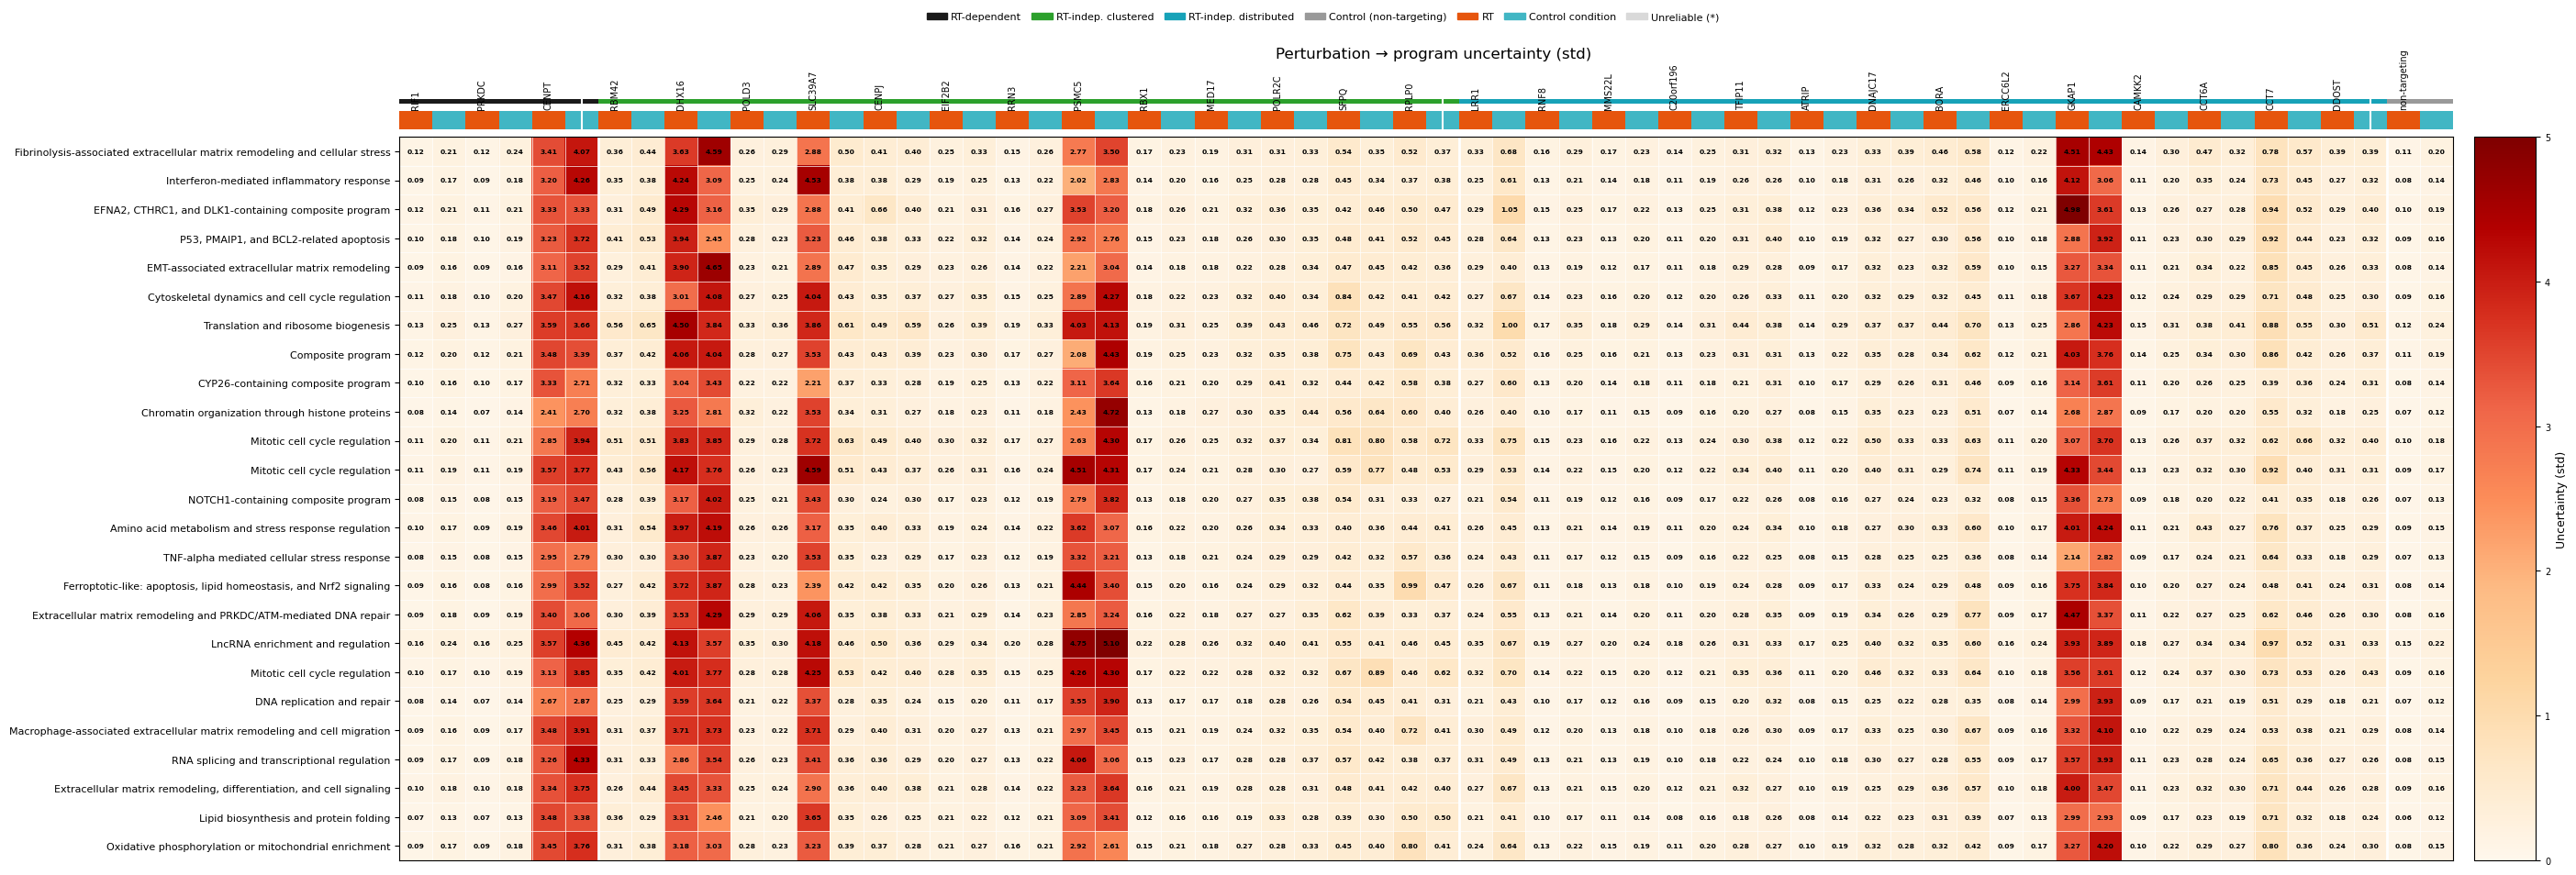

In [10]:


# =========================================================================
# STEP 0: Program names (explicit dict, as provided)
# =========================================================================

PROGRAM_NAMES = {
    0: "Macrophage-associated extracellular matrix remodeling and cell migration",
    1: "Fibrinolysis-associated extracellular matrix remodeling and cellular stress",
    2: "Extracellular matrix remodeling, differentiation, and cell signaling",
    3: "Oxidative phosphorylation or mitochondrial enrichment",
    4: "Cytoskeletal dynamics and cell cycle regulation",
    5: "DNA replication and repair",
    6: "NOTCH1-containing composite program",
    7: "Amino acid metabolism and stress response regulation",
    8: "Chromatin organization through histone proteins",
    9: "LncRNA enrichment and regulation",
    10: "Extracellular matrix remodeling and PRKDC/ATM-mediated DNA repair",
    11: "Mitotic cell cycle regulation",
    12: "Mitotic cell cycle regulation",
    13: "EFNA2, CTHRC1, and DLK1-containing composite program",
    14: "Lipid biosynthesis and protein folding",
    15: "P53, PMAIP1, and BCL2-related apoptosis",
    16: "EMT-associated extracellular matrix remodeling",
    17: "Ferroptotic-like: apoptosis, lipid homeostasis, and Nrf2 signaling",
    18: "RNA splicing and transcriptional regulation",
    19: "Translation and ribosome biogenesis",
    20: "TNF-alpha mediated cellular stress response",
    21: "Mitotic cell cycle regulation",
    22: "Composite program",
    23: "CYP26-containing composite program",
    24: "Interferon-mediated inflammatory response"
}

# =========================================================================
# STEP 1: Gene groupings (including non-targeting control)
# =========================================================================

RT_DEPENDENT = ["RIF1", "PRKDC", "CENPT"]
RT_INDEPENDENT_CLUSTERED = [
    "RBM42", "DHX16", "POLD3", "SLC39A7", "CENPJ", "EIF2B2", "RRN3",
    "PSMC5", "RBX1", "MED17", "POLR2C", "SFPQ", "RPLP0"
]
RT_INDEPENDENT_DISTRIBUTED = [
    "LRR1", "RNF8", "MMS22L", "C20orf196", "TFIP11", "ATRIP", "DNAJC17",
    "BORA", "ERCC6L2", "GKAP1", "CAMKK2", "CCT6A", "CCT7", "DDOST"
]
CONTROL = ["non-targeting"]

GENE_ORDER = RT_DEPENDENT + RT_INDEPENDENT_CLUSTERED + RT_INDEPENDENT_DISTRIBUTED + CONTROL
GENES_OF_INTEREST = GENE_ORDER

GENE_CATEGORY = {}
for g in RT_DEPENDENT:
    GENE_CATEGORY[g] = "RT-dependent"
for g in RT_INDEPENDENT_CLUSTERED:
    GENE_CATEGORY[g] = "RT-independent clustered"
for g in RT_INDEPENDENT_DISTRIBUTED:
    GENE_CATEGORY[g] = "RT-independent distributed"
for g in CONTROL:
    GENE_CATEGORY[g] = "Control"

CATEGORY_COLORS = {
    "RT-dependent": "#1a1a1a",
    "RT-independent clustered": "#2ca02c",
    "RT-independent distributed": "#17a2b8",
    "Control": "#999999",
}
CONDITION_COLORS = {"RT": "#e6550d", "noRT": "#41b6c4"}

# =========================================================================
# STEP 2: Core FIM functions
# =========================================================================

def safe_inv(M, ridge=1e-8):
    """Invert with a small ridge for numerical stability; fall back to pinv if still singular."""
    n = M.shape[0]
    try:
        return np.linalg.inv(M + ridge * np.eye(n))
    except np.linalg.LinAlgError:
        return np.linalg.pinv(M)


def build_sample_name_map(genes_of_interest, suffix):
    """Map clean gene name -> suffixed sample name (e.g. 'BORA' -> 'BORA_RT')."""
    # non-targeting keeps its own naming convention (no clean/suffix split issue,
    # since 'non-targeting_RT' / 'non-targeting_noRT' already match this pattern)
    return {gene: f"{gene}{suffix}" for gene in genes_of_interest}


def get_total_coverage_per_gene(model, genes_of_interest, suffix):
    """Look up total cell count per gene from model.sample_list."""
    network_discretized = model.program_discretized
    name_map = build_sample_name_map(genes_of_interest, suffix)
    coverage = {}
    for gene, sample_name in name_map.items():
        if sample_name in model.sample_list:
            n_cells = (network_discretized[gbm43_hvg.obs['sgRNACond'] == sample_name]).shape[0]
            coverage[gene] = n_cells
        else:
            coverage[gene] = 0
    return coverage


def calculate_fisher_information_matrix(S: np.ndarray) -> np.ndarray:
    """
    Given a num_samples x num_gene_programs matrix S, calculate the Fisher
    information matrix (FIM), split into edge-edge, edge-node, and node-node
    blocks per Eq. 8.
    """
    num_samples = S.shape[0]
    num_gene_programs = S.shape[1]

    average_s_i = S.mean(axis=0).reshape(-1, 1)
    average_s_ij = (S.T @ S) / num_samples
    node_node_interaction = average_s_ij - (average_s_i @ average_s_i.T)

    s_ij = S[:, np.newaxis, :] * S[:, :, np.newaxis]
    rows_to_keep, columns_to_keep = np.triu_indices(num_gene_programs)
    s_ij = s_ij[:, rows_to_keep, columns_to_keep]
    average_s_ij = s_ij.mean(axis=0, keepdims=True)

    s_ijkl = s_ij.T @ s_ij
    average_s_ijkl = s_ijkl / num_samples
    edge_edge_interaction = average_s_ijkl - (average_s_ij.T @ average_s_ij)

    s_ijk = s_ij.T @ S
    average_s_ijk = s_ijk / num_samples
    edge_node_interaction = average_s_ijk - (average_s_ij.T @ average_s_i.T)

    return np.block([[edge_edge_interaction, edge_node_interaction],
                      [edge_node_interaction.T, node_node_interaction]])


def accumulate_fim_per_perturbation_confidence_adaptive_shrinkage(
        model, genes_of_interest, suffix, ridge=1e-8, prior_std=10.0, coverage_scale=50):
    """
    Adaptive shrinkage: prior strength scales with how little coverage a gene has.
    Genes with coverage >> coverage_scale get almost no extra shrinkage; genes with
    coverage << coverage_scale (CENPT, DHX16, GKAP1, PSMC5, SLC39A7) get pulled
    toward the prior, capping their reported std near prior_std instead of
    blowing up numerically.
    """
    network_discretized = model.program_discretized
    num_programs = network_discretized.shape[1]
    num_unique_edges = num_programs * (num_programs + 1) // 2
    name_map = build_sample_name_map(genes_of_interest, suffix)
    target_sample_names = set(name_map.values())

    coverage = get_total_coverage_per_gene(model, genes_of_interest, suffix)

    A_total = np.zeros([num_unique_edges, num_unique_edges])
    S_total = np.zeros([num_unique_edges, num_unique_edges])
    stashed_blocks = {}

    for sample in model.sample_list:
        sample_network_discretized = network_discretized[gbm43_hvg.obs['sgRNACond'] == sample]
        n_cells_c = sample_network_discretized.shape[0]
        sample_fim = calculate_fisher_information_matrix(sample_network_discretized) * n_cells_c

        A_c = sample_fim[:num_unique_edges, :num_unique_edges]
        B_c = sample_fim[:num_unique_edges, num_unique_edges:]
        C_c = sample_fim[num_unique_edges:, num_unique_edges:]

        adaptive_precision = (1.0 / prior_std**2) * (coverage_scale / max(n_cells_c, 1)) * np.eye(num_programs)

        A_total += A_c
        inv_C_c = safe_inv(C_c + adaptive_precision, ridge=ridge)
        S_total += B_c @ inv_C_c @ B_c.T

        if sample in target_sample_names:
            stashed_blocks[sample] = (B_c, C_c, inv_C_c, adaptive_precision)

    missing_samples = target_sample_names - set(stashed_blocks.keys())
    if missing_samples:
        missing_genes = [g for g, s in name_map.items() if s in missing_samples]
        print(f"Warning: genes not found (suffix='{suffix}'), skipped: {sorted(missing_genes)}")

    perturbation_confidence = {}
    for sample_name, (B_i, C_i, inv_C_i, adaptive_precision_i) in stashed_blocks.items():
        gene_name = sample_name[:-len(suffix)]

        A_prime = A_total - S_total + (B_i @ inv_C_i @ B_i.T)
        A_prime = (A_prime + A_prime.T) / 2
        inv_A_prime = safe_inv(A_prime, ridge=ridge)

        field_precision = (C_i - B_i.T @ inv_A_prime @ B_i) + adaptive_precision_i
        field_precision = (field_precision + field_precision.T) / 2

        field_covariance = safe_inv(field_precision, ridge=ridge)
        perturbation_confidence[gene_name] = np.sqrt(np.clip(np.diag(field_covariance), 0, None))

    print(f"\nCoverage-based shrinkage applied (prior_std={prior_std}, coverage_scale={coverage_scale}):")
    for gene, n in sorted(coverage.items(), key=lambda x: x[1]):
        tag = "  <-- heavy shrinkage" if n < coverage_scale else ""
        print(f"  {gene:<15} n_cells={n:>5}{tag}")

    return perturbation_confidence, coverage

# =========================================================================
# STEP 3: Compute confidence for both models
# =========================================================================

RT_perturbation_confidence, RT_coverage = accumulate_fim_per_perturbation_confidence_adaptive_shrinkage(
    RT_noRTNormalized_model, GENES_OF_INTEREST, suffix="_RT", prior_std=10, coverage_scale=50
)
noRT_perturbation_confidence, noRT_coverage = accumulate_fim_per_perturbation_confidence_adaptive_shrinkage(
    noRT_model, GENES_OF_INTEREST, suffix="_noRT", prior_std=10, coverage_scale=50
)

# =========================================================================
# STEP 4: Build tidy dataframe (keyed by program_idx -- avoids duplicate-name collisions)
# =========================================================================

def confidence_dict_to_df(confidence_dict, model, condition_label):
    num_programs = model.program_discretized.shape[1]
    rows = []
    for perturbation, std_vec in confidence_dict.items():
        for prog_idx in range(num_programs):
            rows.append({
                "perturbation": perturbation,
                "program_idx": prog_idx,
                "program": PROGRAM_NAMES.get(prog_idx, f"Program_{prog_idx}"),
                "uncertainty_std": std_vec[prog_idx],
                "condition": condition_label
            })
    return pd.DataFrame(rows)

RT_confidence_df = confidence_dict_to_df(RT_perturbation_confidence, RT_noRTNormalized_model, "RT")
noRT_confidence_df = confidence_dict_to_df(noRT_perturbation_confidence, noRT_model, "noRT")
combined_confidence_df = pd.concat([RT_confidence_df, noRT_confidence_df], ignore_index=True)
combined_confidence_df.to_csv(os.path.join(SAVE_PATH, "perturbation_program_confidence.csv"), index=False)

print("\nSanity check on uncertainty range:")
print(combined_confidence_df["uncertainty_std"].describe())

UNRELIABLE_GENES = set(
    combined_confidence_df.loc[combined_confidence_df["uncertainty_std"].isna(), "perturbation"].unique()
)
print(f"\nRendering all {len(GENE_ORDER)} genes; {len(UNRELIABLE_GENES)} flagged unreliable (NaN): "
      f"{sorted(UNRELIABLE_GENES)}")

# =========================================================================
# STEP 5: Program row order (top to bottom, as specified)
# =========================================================================

PROGRAM_ORDER = [1, 24, 13, 15, 16, 4, 19, 22, 23, 8, 11, 21, 6, 7, 20,
                 17, 10, 9, 12, 5, 0, 18, 2, 14, 3]

num_programs = RT_noRTNormalized_model.program_discretized.shape[1]
assert set(PROGRAM_ORDER) == set(range(num_programs)), \
    f"PROGRAM_ORDER doesn't cover all {num_programs} program indices -- check for typos/omissions"

program_names_ordered = [PROGRAM_NAMES.get(i, f"Program_{i}") for i in PROGRAM_ORDER]

# =========================================================================
# STEP 6: Build the matrix
# =========================================================================

col_tuples = [(gene, cond) for gene in GENE_ORDER for cond in ["RT", "noRT"]]

matrix = pd.DataFrame(index=range(num_programs), columns=pd.MultiIndex.from_tuples(col_tuples), dtype=float)

for gene, cond in col_tuples:
    sub = combined_confidence_df[
        (combined_confidence_df["perturbation"] == gene) &
        (combined_confidence_df["condition"] == cond)
    ]
    for _, row in sub.iterrows():
        matrix.loc[row["program_idx"], (gene, cond)] = row["uncertainty_std"]

matrix = matrix.reindex(PROGRAM_ORDER)
matrix.index = program_names_ordered
n_rows, n_cols = matrix.shape

# =========================================================================
# STEP 7: Plot
# =========================================================================

fig = plt.figure(figsize=(0.42 * n_cols + 4, 0.34 * n_rows + 2.0))
gs = GridSpec(3, 2, height_ratios=[0.06, 0.25, 10], width_ratios=[10, 0.3],
              hspace=0.03, wspace=0.02, top=0.90)

ax_cat = fig.add_subplot(gs[0, 0])
ax_cond = fig.add_subplot(gs[1, 0])
ax_heat = fig.add_subplot(gs[2, 0])
ax_cbar = fig.add_subplot(gs[2, 1])

# --- Category bar (drawn as rectangle patches, not imshow, so there is
#     nothing for any backend to interpolate/blend between cells) ---
for j, (g, c) in enumerate(col_tuples):
    ax_cat.add_patch(mpatches.Rectangle(
        (j, 0), 1, 1,
        facecolor=CATEGORY_COLORS[GENE_CATEGORY[g]],
        edgecolor='none'
    ))
ax_cat.set_xlim(0, n_cols)
ax_cat.set_ylim(0, 1)
ax_cat.set_xticks([]); ax_cat.set_yticks([])
for spine in ax_cat.spines.values():
    spine.set_visible(False)

# --- Condition bar with gene labels (rectangle patches, same reasoning as above) ---
for j, (g, c) in enumerate(col_tuples):
    ax_cond.add_patch(mpatches.Rectangle(
        (j, 0), 1, 1,
        facecolor=CONDITION_COLORS[c],
        edgecolor='none'
    ))
ax_cond.set_xlim(0, n_cols)
ax_cond.set_ylim(0, 1)
ax_cond.set_yticks([])
for spine in ax_cond.spines.values():
    spine.set_visible(False)
tick_positions = [i + 0.5 for i in range(0, n_cols, 2)]
tick_labels = [f"{g}*" if g in UNRELIABLE_GENES else g for g in GENE_ORDER]
ax_cond.set_xticks(tick_positions)
ax_cond.set_xticklabels(tick_labels, rotation=90, fontsize=7, ha='center')
ax_cond.xaxis.set_ticks_position('top')
ax_cond.tick_params(axis='x', pad=2, length=0)

# --- Group separators ---
group_boundaries = [
    len(RT_DEPENDENT) * 2,
    (len(RT_DEPENDENT) + len(RT_INDEPENDENT_CLUSTERED)) * 2,
    (len(RT_DEPENDENT) + len(RT_INDEPENDENT_CLUSTERED) + len(RT_INDEPENDENT_DISTRIBUTED)) * 2,
]

# --- Heatmap ---
heat_data = matrix.values.astype(float)
finite_vals = heat_data[~np.isnan(heat_data)]

# Fixed color scale: 0-5 std
vmin = 0
vmax = 5

# White -> orange -> red intensity scale
cmap = plt.cm.OrRd.copy()
cmap.set_bad(color='#d9d9d9')

masked_data = np.ma.masked_invalid(heat_data)

im = ax_heat.imshow(
    masked_data,
    aspect='auto',
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation='nearest'
)

ax_heat.set_yticks(range(n_rows))
ax_heat.set_yticklabels(matrix.index, fontsize=8)
ax_heat.set_xticks([])

for boundary in group_boundaries:
    ax_heat.axvline(boundary - 0.5, color='white', linewidth=2)
    ax_cond.axvline(boundary - 0.5, color='white', linewidth=1.5)
    ax_cat.axvline(boundary - 0.5, color='white', linewidth=1.5)

for i in range(n_rows):
    for j in range(n_cols):
        val = heat_data[i, j]

        if np.isnan(val):
            ax_heat.text(
                j, i, "N/A",
                ha='center',
                va='center',
                fontsize=4.5,
                color='#666666'
            )
        else:
            # Black text on light cells;
            # white text only on darker orange/red cells
            #text_color = 'white' if val > vmax * 0.65 else 'black'

            ax_heat.text(
                j, i, f"{val:.2f}",
                ha='center',
                va='center',
                fontsize=5.5,
                color=text_color,
                fontweight='bold'
            )

ax_heat.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax_heat.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax_heat.grid(which='minor', color='white', linewidth=0.5)
ax_heat.tick_params(which='minor', length=0)

cbar = fig.colorbar(im, cax=ax_cbar)
cbar.set_label("Uncertainty (std)", fontsize=9)
cbar.ax.tick_params(labelsize=7)

# Fixed color scale: 0-5 std
vmin = 0
vmax = 5
im = ax_heat.imshow(masked_data, aspect='auto', cmap=cmap, vmin=0, vmax=vmax)
# White -> red intensity scale



legend_elements = [
    mpatches.Patch(color=CATEGORY_COLORS["RT-dependent"], label="RT-dependent"),
    mpatches.Patch(color=CATEGORY_COLORS["RT-independent clustered"], label="RT-indep. clustered"),
    mpatches.Patch(color=CATEGORY_COLORS["RT-independent distributed"], label="RT-indep. distributed"),
    mpatches.Patch(color=CATEGORY_COLORS["Control"], label="Control (non-targeting)"),
    mpatches.Patch(color=CONDITION_COLORS["RT"], label="RT"),
    mpatches.Patch(color=CONDITION_COLORS["noRT"], label="Control condition"),
    mpatches.Patch(color='#d9d9d9', label="Unreliable (*)"),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.46, 1.0),
           fontsize=8, frameon=False, ncol=7, columnspacing=1.0, handletextpad=0.4)

fig.suptitle("Perturbation \u2192 program uncertainty (std)", fontsize=12, y=0.955)

# Save PDF (vector) alongside the PNG using matplotlib's default backend,
# so this doesn't depend on the 'cairo' backend being installed.
plt.savefig(os.path.join(SAVE_PATH, 'perturbation_program_uncertainty_heatmap.pdf'),
            format='pdf', bbox_inches='tight')
plt.savefig(os.path.join(SAVE_PATH, 'perturbation_program_uncertainty_heatmap.png'),
            dpi=300, bbox_inches='tight')

# Optional: also save a copy to a specific local folder, if it exists on this machine.
_extra_pdf_dir = '/Users/krishraval/Downloads/edges_review'
if os.path.isdir(_extra_pdf_dir):
    plt.savefig(os.path.join(_extra_pdf_dir, 'perturbation_program_uncertainty_heatmap.pdf'),
                format='pdf', bbox_inches='tight')

plt.show()